# 03 - Workflow model and metrics

The model represents this workflow from the fleet's perspective:

1. Dispatcher / driver decides to join the JFK taxi queue at some hour (the intervention; not in the data).
2. Driver waits in the queue (not in the data either, TLC records start at the meter).
3. Meter on at JFK (pickup event, `tpep_pickup_datetime`, zone 132).
4. Meter off in Manhattan (dropoff event, `tpep_dropoff_datetime`, a Manhattan zone).
5. Payment: flat $70 fare plus tolls, surcharges, tip (`fare_amount`, `payment_type`).

The measurable outcome is steps 3 to 4: trip duration and the effective hourly value of the $70 fare.
The pipeline stores this as a small star-shaped relational model in `data/processed/jfk_trips.duckdb`.
This notebook reads it (read-only) and walks through the joins and metrics.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make the pipeline package importable

import duckdb
import pandas as pd
from IPython.display import Image, display
from pipeline import config
from pipeline.metrics import steer

pd.set_option("display.width", 200)

In [2]:
db = duckdb.connect(str(config.DB_PATH), read_only=True)
q = lambda sql: db.sql(sql).df()
q('''SELECT table_name, table_type FROM information_schema.tables ORDER BY table_type, table_name''')

,table_name,table_type
0,dim_hour,BASE TABLE
1,dim_vendor,BASE TABLE
2,dim_zone,BASE TABLE
3,trip_fact,BASE TABLE
4,trips_validated,BASE TABLE
5,weather_hourly,BASE TABLE
6,trip_analysis,VIEW
7,trip_events,VIEW


In [3]:
pd.DataFrame([(t, db.execute(f"SELECT count(*) FROM {t}").fetchone()[0])
              for t in ["dim_zone", "dim_vendor", "dim_hour", "weather_hourly", "trips_validated", "trip_fact"]],
             columns=["table", "rows"])

,table,rows
0,dim_zone,265
1,dim_vendor,4
2,dim_hour,2184
3,weather_hourly,2184
4,trips_validated,212688
5,trip_fact,199156


- `dim_zone`: TLC taxi zones (265 rows, from the lookup CSV).
- `dim_vendor`: the four TPEP vendors from the data dictionary.
- `dim_hour`: one row per clock hour of each month, with day type and the weather for that hour (from the API).
- `trips_validated`: every JFK -> Manhattan zone-pair trip with a true/false column per validation rule. Nothing is deleted here.
- `trip_fact`: only the trips that passed every exclude rule. One row per trip, keys to the three dimensions.
- `trip_events` (view): each trip as two events, meter on and meter off.
- `trip_analysis` (view): `trip_fact` joined to its dimensions. The metrics are computed from this.

Keys and joins: `trip_fact.pickup_hour_ts -> dim_hour.hour_ts`, `trip_fact.do_zone_id -> dim_zone.zone_id`,
`trip_fact.pu_zone_id -> dim_zone.zone_id`, `trip_fact.vendor_id -> dim_vendor.vendor_id`. The pipeline checks there are no orphan keys before it continues.

One trip, shown as events:


In [4]:
one = q("SELECT trip_id FROM trip_fact WHERE source_month = '2026-05' ORDER BY trip_id LIMIT 1 OFFSET 30000").trip_id[0]
q(f'''SELECT e.trip_id, e.event, e.event_ts, e.zone_id, z.zone_name, z.borough
      FROM trip_events e JOIN dim_zone z ON z.zone_id = e.zone_id
      WHERE e.trip_id = '{one}' ORDER BY e.event_ts''')

,trip_id,event,event_ts,zone_id,zone_name,borough
0,2026-05-032141,meter_on,2026-05-14 19:21:44,132,JFK Airport,Queens
1,2026-05-032141,meter_off,2026-05-14 20:04:45,224,Stuy Town/Peter Cooper Village,Manhattan


In [5]:
q(f'''SELECT trip_id, pickup_hour, day_type, precipitation_mm, is_wet, do_zone_name, vendor_name,
             round(duration_min, 1) AS duration_min, fare_amount, is_long, round(fare_per_trip_hour, 2) AS fare_per_trip_hour
      FROM trip_analysis WHERE trip_id = '{one}' ''')

,trip_id,pickup_hour,day_type,precipitation_mm,is_wet,do_zone_name,vendor_name,duration_min,fare_amount,is_long,fare_per_trip_hour
0,2026-05-032141,19,weekday,0.0,False,Stuy Town/Peter Cooper Village,Curb Mobility,43.0,70.0,False,97.64


## Sizing the problem

Notebook 01 already sized the problem on the raw data. Here are the same numbers after validation,
from `outputs/metrics_by_month.csv`:


In [6]:
monthly = pd.read_csv(config.OUTPUT_DIR / "metrics_by_month.csv")
monthly[["source_month", "candidates", "valid", "long_trip_rate", "median_min", "p90_min", "fare_per_trip_hour",
         "quality_exclusion_rate"]]

,source_month,candidates,valid,long_trip_rate,median_min,p90_min,fare_per_trip_hour,quality_exclusion_rate
0,2026-04,69945,65594,0.2797,50.2,72.8,80.76,0.0164
1,2026-05,72049,67271,0.3986,54.7,80.9,74.07,0.0182
2,2026-06,70694,66291,0.3546,53.5,76.9,76.49,0.0181
3,all,212688,199156,0.3448,52.7,77.2,76.98,0.0176


In [7]:
hourly = pd.read_csv(config.OUTPUT_DIR / "metrics_by_hour.csv")
wd = hourly[hourly.day_type == "weekday"].set_index("pickup_hour")
worst = wd.long_trip_rate.idxmax()
wd.loc[[worst, 21]]   # the worst weekday hour vs 21:00, a good hour that still has plenty of trips

,day_type,trips,long_trip_rate,median_min,p90_min,fare_per_trip_hour,advice
pickup_hour,,,,,,,
14,weekday,10296,0.7857,70.2,89.1,58.99,steer away
21,weekday,7850,0.0268,39.0,50.6,104.21,steer toward


Between 28% and 40% of flat-fare JFK -> Manhattan trips go over an hour, depending on the month
(notebook 01 found about the same, 34.4%, on the raw data before any rules). And it's very uneven by hour. On weekdays a 14:00 pickup has a median of 70 minutes and 79% of trips go over an hour, while
a 21:00 pickup has a median of 39 minutes and under 3% go over an hour. Same $70. That's roughly $59 vs $104 per hour on the meter,
before counting any queue time. So hour of pickup matters a lot for this run.

## Metrics by pickup hour


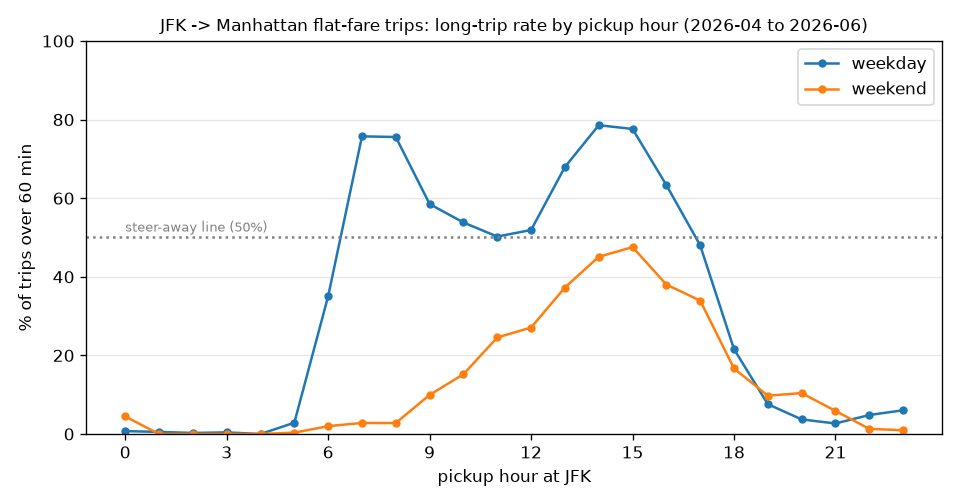

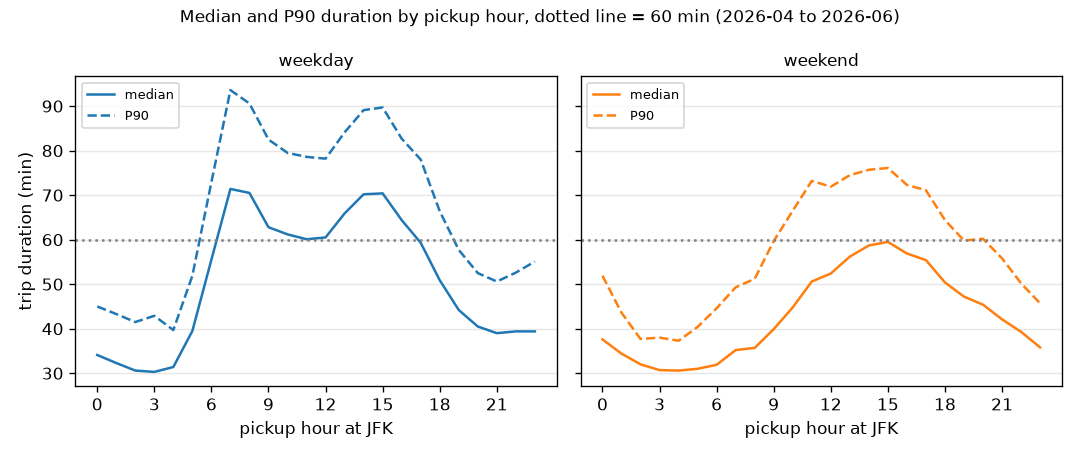

In [8]:
display(Image(filename=str(config.OUTPUT_DIR / "chart_long_trip_rate_by_hour.png")))
display(Image(filename=str(config.OUTPUT_DIR / "chart_duration_by_hour.png")))

In [9]:
hourly.pivot(index="pickup_hour", columns="day_type", values=["long_trip_rate", "median_min", "advice"])

long_trip_rate         median_min                advice               
day_type           weekday weekend    weekday weekend       weekday        weekend
pickup_hour                                                                       
0                   0.0074  0.0446       34.1    37.6  steer toward   steer toward
1                   0.0053     0.0       32.3    34.4  steer toward   steer toward
2                   0.0027     0.0       30.6    32.0  steer toward   steer toward
3                   0.0041     0.0       30.3    30.7  steer toward  too few trips
4                      0.0     0.0       31.4    30.6  steer toward  too few trips
5                   0.0287  0.0034       39.5    31.0  steer toward   steer toward
6                   0.3506    0.02       55.5    31.9       neutral   steer toward
7                   0.7574  0.0281       71.4    35.2    steer away   steer toward
8                   0.7557  0.0279       70.5    35.7    steer away   steer toward
9                   0.5851  0.0995       62.8    39.9    steer away   steer toward
10                  0.5382  0.1521       61.2    44.8    steer away        neutral
11                  0.5024  0.2456       60.1    50.6    steer away        neutral
12                  0.5191  0.2709       60.5    52.4    steer away        neutral
13                  0.6793  0.3727       65.9    56.2    steer away        neutral
14                  0.7857  0.4509       70.2    58.7    steer away        neutral
15                  0.7762  0.4756       70.4    59.5    steer away        neutral
16                  0.6334  0.3802       64.4    56.9    steer away        neutral
17                  0.4801  0.3394       59.3    55.4       neutral        neutral
18                  0.2159  0.1667       50.9    50.4       neutral        neutral
19                  0.0759  0.0975       44.2    47.2  steer toward   steer toward
20                  0.0371  0.1041       40.5    45.4  steer toward        neutral
21                  0.0268  0.0588       39.0    42.1  steer toward   steer toward
22                  0.0483  0.0131       39.4    39.3  steer toward   steer toward
23                  0.0604  0.0095       39.4    35.8  steer toward   steer toward

On weekdays every hour from 07:00 to 16:00 has half or more of its trips going over an hour. There's a
small dip around 11:00-12:00 (about 50-52%), and the worst hours are 07:00-08:00 and 14:00-15:00 (76-79%).
From 19:00 through the night it's good. Weekends are much flatter, the worst is 15:00 at about 48%.

Is the hourly pattern stable month to month, or is it one month driving it?


In [10]:
q('''SELECT pickup_hour, source_month, round(avg(CASE WHEN is_long THEN 1 ELSE 0 END), 3) AS long_trip_rate
     FROM trip_analysis WHERE day_type = 'weekday'
     GROUP BY ALL''').pivot(index="pickup_hour", columns="source_month", values="long_trip_rate")

source_month,2026-04,2026-05,2026-06
pickup_hour,,,
0,0.001,0.019,0.004
1,0.003,0.010,0.003
2,0.007,0.004,0.000
3,0.000,0.000,0.009
4,0.000,0.000,0.000
5,0.003,0.043,0.034
6,0.269,0.446,0.332
7,0.640,0.857,0.778
8,0.641,0.826,0.785


The shape is the same in all three months (bad 07:00-16:00, good from 19:00). The level moves: April was
lighter than May and June at most daytime hours. So the advice by hour looks stable, but the exact percentages
should be refreshed monthly, which is what the pipeline is for.

## Judgement call: defining the run by zone pair, not by rate code

For comparison, the same quality rules are applied using only `RatecodeID = 2` as the route definition:


In [11]:
glob = str(config.RAW_DIR / "trips" / "yellow_tripdata_*.parquet")
alt = db.sql(f'''
    SELECT CASE WHEN dayofweek(tpep_pickup_datetime) IN (0, 6) THEN 'weekend' ELSE 'weekday' END AS day_type,
           hour(tpep_pickup_datetime) AS pickup_hour, count(*) AS trips_ratecode_def,
           round(avg(CASE WHEN date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) > 3600
                     THEN 1 ELSE 0 END), 4) AS long_rate_ratecode_def
    FROM read_parquet('{glob}', filename=true, union_by_name=true)
    WHERE RatecodeID = 2 AND fare_amount > 0
      AND strftime(tpep_pickup_datetime, '%Y-%m') = substr(filename, -15, 7)
      AND date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 60.0 BETWEEN 10 AND 180
    GROUP BY ALL''').df()
alt["advice_ratecode_def"] = alt.rename(columns={"trips_ratecode_def": "trips",
                                                 "long_rate_ratecode_def": "long_trip_rate"}).apply(steer, axis=1)
cmp = hourly.merge(alt, on=["day_type", "pickup_hour"])
print("trips, zone-pair definition:", hourly.trips.sum(), "  trips, rate-code definition:", alt.trips_ratecode_def.sum())
cmp[cmp.advice != cmp.advice_ratecode_def][["day_type", "pickup_hour", "trips", "long_trip_rate", "advice",
                                            "trips_ratecode_def", "long_rate_ratecode_def", "advice_ratecode_def"]]

trips, zone-pair definition: 199156   trips, rate-code definition: 260659


,day_type,pickup_hour,trips,long_trip_rate,advice,trips_ratecode_def,long_rate_ratecode_def,advice_ratecode_def
10,weekday,10,3549,0.5382,steer away,5243,0.4722,neutral
11,weekday,11,5739,0.5024,steer away,8061,0.4552,neutral
17,weekday,17,10443,0.4801,neutral,13202,0.5311,steer away
27,weekend,3,31,0.0000,too few trips,192,0.0104,steer toward
28,weekend,4,51,0.0000,too few trips,504,0.0218,steer toward


The rate-code definition pulls in about 61,500 extra trips that aren't the JFK -> Manhattan run
(mostly Manhattan -> JFK). The overall numbers only move a little, but the hourly advice changes in five
places: weekday 10:00 and 11:00 would drop from "steer away" to "neutral", weekday 17:00 would flip from
"neutral" to "steer away", and weekend 03:00-04:00 would get a "steer toward" that is really based on trips
going *to* the airport. Drivers would get the advice per hour, so these flips would actually change what
some of them are told.

## Does rain go with longer trips?


In [12]:
monthly[["source_month", "wet_trips", "long_rate_wet", "long_rate_dry", "wet_minus_dry_same_hour"]]

,source_month,wet_trips,long_rate_wet,long_rate_dry,wet_minus_dry_same_hour
0,2026-04,4394,0.2740,0.2801,0.0441
1,2026-05,5016,0.3563,0.4020,-0.0928
2,2026-06,5307,0.4976,0.3421,0.1260
3,all,14717,0.3827,0.3417,0.0364


The raw wet vs dry comparison mixes two things because rain is not evenly distributed across hours. The
analysis also compares wet and dry trips inside the same day type and pickup hour, then averages the gaps weighted by wet trips
(`wet_minus_dry_same_hour`). Over the three months wet hours come out a few points worse, but the sign flips
by month (May is negative), and there are only a few thousand wet-hour trips a month. The data does not show a
stable rain effect suitable for operational guidance. Any observed difference is only an association: wet
days can differ in other ways too (more people wanting a cab, for one), and the weather point is at JFK, not
along the route.
